# CanAI Cafe - EDA & Business Insights
**Owner:** Nikhil Khatri  
**Input:** `../data/clean/data_clean.csv`  
**Output:** charts saved to `../outputs/charts/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
CHARTS_DIR = '../outputs/charts/'
os.makedirs(CHARTS_DIR, exist_ok=True)

## 1. Load Clean Data

In [2]:
df = pd.read_csv('../data/clean/data_clean.csv', parse_dates=['Transaction Date'])
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 9483 rows, 10 columns


,Row_ID,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Province
0,1,TXN_9687814,Coffee,2,3.5,7.0,Digital Wallet,In-store,2023-09-28,British Columbia
1,2,TXN_7002925,Refresher,2,5.0,10.0,Cash,Unknown,2023-05-02,Newfoundland and Labrador
2,3,TXN_7668262,Donut,1,2.0,2.0,Digital Wallet,In-store,2023-11-27,British Columbia
3,4,TXN_9390285,Coffee,1,3.5,3.5,Unknown,Takeaway,2023-05-11,Newfoundland and Labrador
4,5,TXN_7321503,Tea,1,3.0,3.0,Credit Card,Takeaway,2023-09-15,British Columbia


### 1.1 Data Types

In [3]:
df.dtypes

Row_ID                       int64
Transaction ID              object
Item                        object
Quantity                     int64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
Province                    object
dtype: object

### 1.2 Nulls & "Unknown" Values

In [4]:
print("Null counts per column:")
print(df.isnull().sum())
print(f"\n'Unknown' counts per column:")
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'Unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(df) * 100
        print(f"  {col}: {unknown_count} ({pct:.1f}%)")

Null counts per column:
Row_ID              0
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Province            0
dtype: int64

'Unknown' counts per column:
  Payment Method: 524 (5.5%)
  Location: 832 (8.8%)
  Province: 396 (4.2%)


### 1.3 Summary Statistics

In [5]:
print(f"Total revenue: ${df['Total Spent'].sum():,.2f}")
print(f"Records: {len(df):,}")
print(f"Date range: {df['Transaction Date'].min().date()} to {df['Transaction Date'].max().date()}")
print(f"\nUnique values:")
print(f"  Items: {df['Item'].nunique()} - {sorted(df['Item'].unique())}")
print(f"  Locations: {df['Location'].nunique()} - {sorted(df['Location'].unique())}")
print(f"  Provinces: {df['Province'].nunique()} - {sorted(df['Province'].unique())}")
print(f"  Payment Methods: {df['Payment Method'].nunique()} - {sorted(df['Payment Method'].unique())}")

Total revenue: $81,932.50
Records: 9,483
Date range: 2023-01-01 to 2023-12-31

Unique values:
  Items: 8 - ['Coffee', 'Cookie', 'Donut', 'Juice', 'Refresher', 'Salad', 'Sandwich', 'Tea']
  Locations: 3 - ['In-store', 'Takeaway', 'Unknown']
  Provinces: 6 - ['British Columbia', 'Manitoba', 'Newfoundland and Labrador', 'Ontario', 'Saskatchewan', 'Unknown']
  Payment Methods: 4 - ['Cash', 'Credit Card', 'Digital Wallet', 'Unknown']


In [6]:
df[['Quantity', 'Price Per Unit', 'Total Spent']].describe()

,Quantity,Price Per Unit,Total Spent
count,9483.000000,9483.000000,9483.000000
mean,1.988506,4.342929,8.639935
std,1.086326,2.199662,6.893396
min,1.000000,2.000000,2.000000
25%,1.000000,3.000000,3.500000
50%,2.000000,3.500000,7.000000
75%,3.000000,5.000000,10.500000
max,5.000000,9.000000,45.000000


## 2. Sales Trends Over Time

Aggregate revenue and transaction volume at daily, weekly, and monthly grains. Identify trends, seasonality, and anomalies.

### 2.1 Monthly Revenue & Transaction Volume

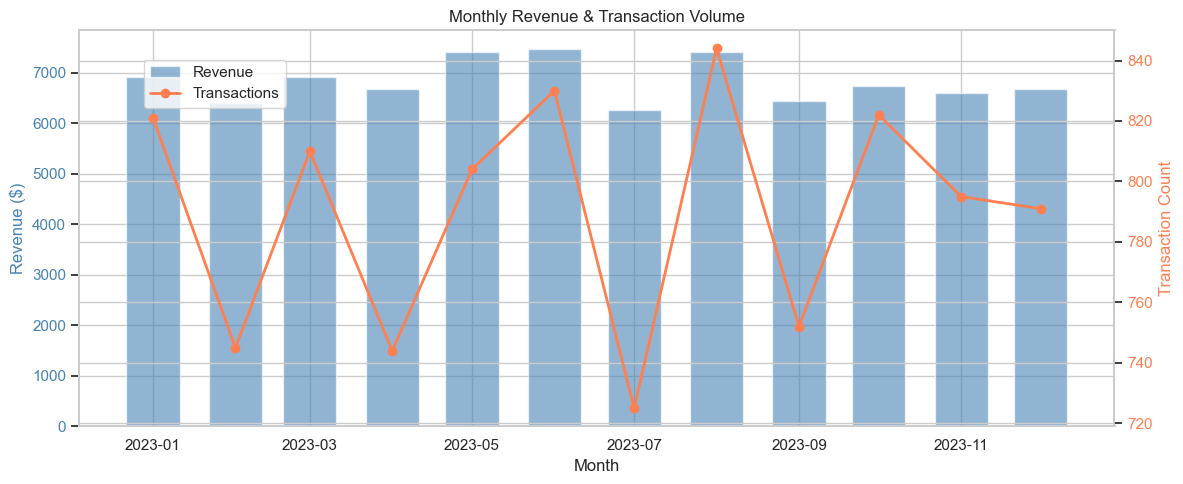

month_label  revenue  transactions  units
   Jan 2023   6911.5           821   1670
   Feb 2023   6403.5           745   1510
   Mar 2023   6911.5           810   1613
   Apr 2023   6684.0           744   1508
   May 2023   7420.5           804   1619
   Jun 2023   7470.0           830   1667
   Jul 2023   6268.0           725   1423
   Aug 2023   7406.5           844   1678
   Sep 2023   6435.0           752   1485
   Oct 2023   6747.5           822   1571
   Nov 2023   6600.5           795   1543
   Dec 2023   6674.0           791   1570


In [7]:
monthly = df.set_index('Transaction Date').resample('MS').agg(
    revenue=('Total Spent', 'sum'),
    transactions=('Transaction ID', 'count'),
    units=('Quantity', 'sum')
).reset_index()
monthly['month_label'] = monthly['Transaction Date'].dt.strftime('%b %Y')

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(monthly['Transaction Date'], monthly['revenue'], width=20, alpha=0.6, color='steelblue', label='Revenue')
ax1.set_ylabel('Revenue ($)', color='steelblue')
ax1.set_xlabel('Month')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(monthly['Transaction Date'], monthly['transactions'], color='coral', marker='o', linewidth=2, label='Transactions')
ax2.set_ylabel('Transaction Count', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

ax1.set_title('Monthly Revenue & Transaction Volume')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}monthly_revenue_transactions.png', dpi=150, bbox_inches='tight')
plt.show()

print(monthly[['month_label', 'revenue', 'transactions', 'units']].to_string(index=False))

### 2.2 Month-over-Month Growth Rates

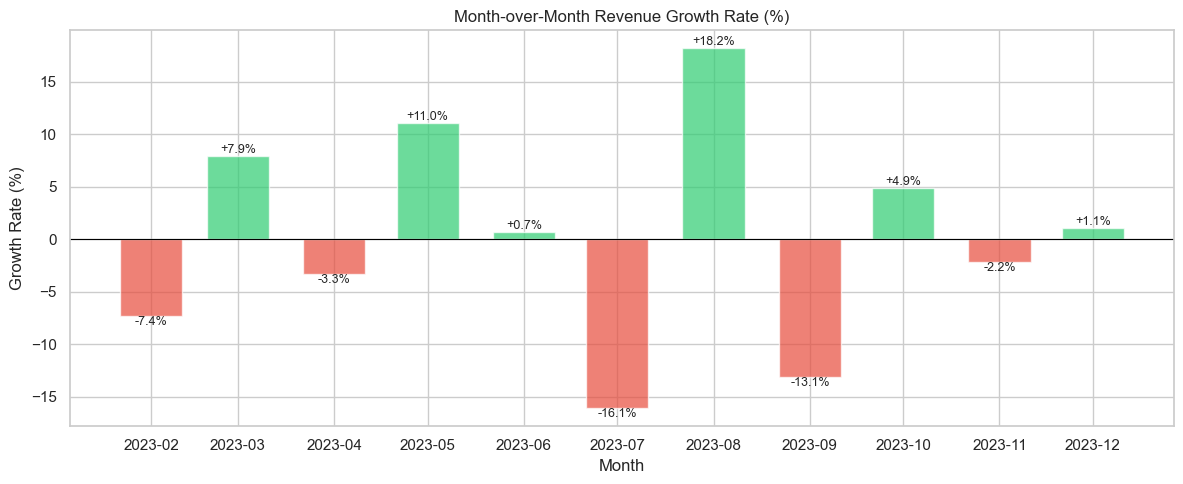

month_label  revenue_growth  txn_growth
   Jan 2023             NaN         NaN
   Feb 2023       -7.350069   -9.257004
   Mar 2023        7.933162    8.724832
   Apr 2023       -3.291615   -8.148148
   May 2023       11.018851    8.064516
   Jun 2023        0.667071    3.233831
   Jul 2023      -16.091031  -12.650602
   Aug 2023       18.163689   16.413793
   Sep 2023      -13.116857  -10.900474
   Oct 2023        4.856255    9.308511
   Nov 2023       -2.178585   -3.284672
   Dec 2023        1.113552   -0.503145


In [8]:
monthly['revenue_growth'] = monthly['revenue'].pct_change() * 100
monthly['txn_growth'] = monthly['transactions'].pct_change() * 100

fig, ax = plt.subplots(figsize=(12, 5))
growth = monthly.iloc[1:]
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in growth['revenue_growth']]
ax.bar(growth['Transaction Date'], growth['revenue_growth'], width=20, color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Month-over-Month Revenue Growth Rate (%)')
ax.set_xlabel('Month')
ax.set_ylabel('Growth Rate (%)')

for i, row in growth.iterrows():
    ax.annotate(f"{row['revenue_growth']:+.1f}%",
                xy=(row['Transaction Date'], row['revenue_growth']),
                ha='center', va='bottom' if row['revenue_growth'] >= 0 else 'top',
                fontsize=9)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}mom_revenue_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print(monthly[['month_label', 'revenue_growth', 'txn_growth']].to_string(index=False))

### 2.3 Weekly Revenue Trend

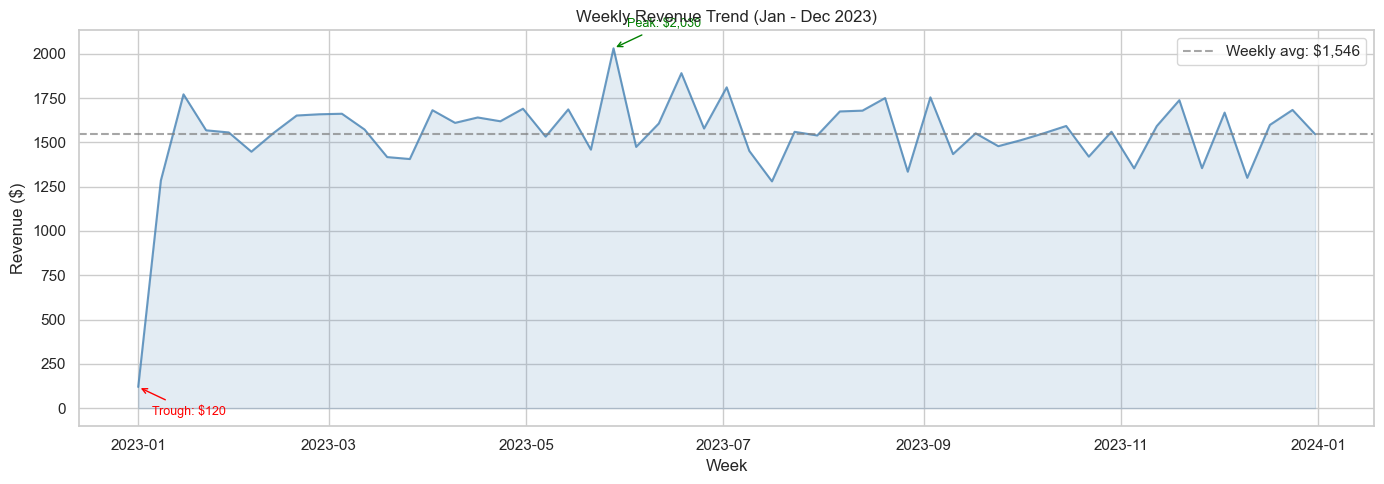

In [9]:
weekly = df.set_index('Transaction Date').resample('W').agg(
    revenue=('Total Spent', 'sum'),
    transactions=('Transaction ID', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly['Transaction Date'], weekly['revenue'], color='steelblue', linewidth=1.5, alpha=0.8)
ax.fill_between(weekly['Transaction Date'], weekly['revenue'], alpha=0.15, color='steelblue')

mean_rev = weekly['revenue'].mean()
ax.axhline(y=mean_rev, color='gray', linestyle='--', alpha=0.7, label=f'Weekly avg: ${mean_rev:,.0f}')

peak_idx = weekly['revenue'].idxmax()
trough_idx = weekly['revenue'].idxmin()
ax.annotate(f"Peak: ${weekly.loc[peak_idx, 'revenue']:,.0f}",
            xy=(weekly.loc[peak_idx, 'Transaction Date'], weekly.loc[peak_idx, 'revenue']),
            xytext=(10, 15), textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='green'), color='green')
ax.annotate(f"Trough: ${weekly.loc[trough_idx, 'revenue']:,.0f}",
            xy=(weekly.loc[trough_idx, 'Transaction Date'], weekly.loc[trough_idx, 'revenue']),
            xytext=(10, -20), textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='red'), color='red')

ax.set_title('Weekly Revenue Trend (Jan - Dec 2023)')
ax.set_xlabel('Week')
ax.set_ylabel('Revenue ($)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}weekly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Daily Revenue Trend

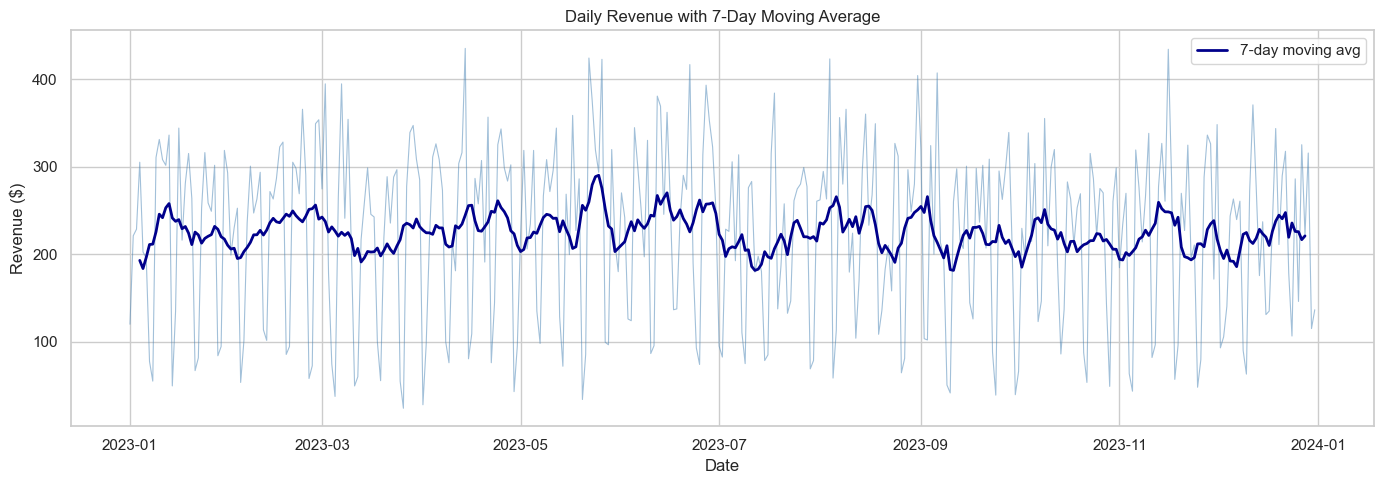

In [10]:
daily = df.set_index('Transaction Date').resample('D').agg(
    revenue=('Total Spent', 'sum'),
    transactions=('Transaction ID', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['Transaction Date'], daily['revenue'], color='steelblue', linewidth=0.8, alpha=0.5)
daily['revenue_7d'] = daily['revenue'].rolling(7, center=True).mean()
ax.plot(daily['Transaction Date'], daily['revenue_7d'], color='darkblue', linewidth=2, label='7-day moving avg')
ax.set_title('Daily Revenue with 7-Day Moving Average')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue ($)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}daily_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Day-of-Week Patterns

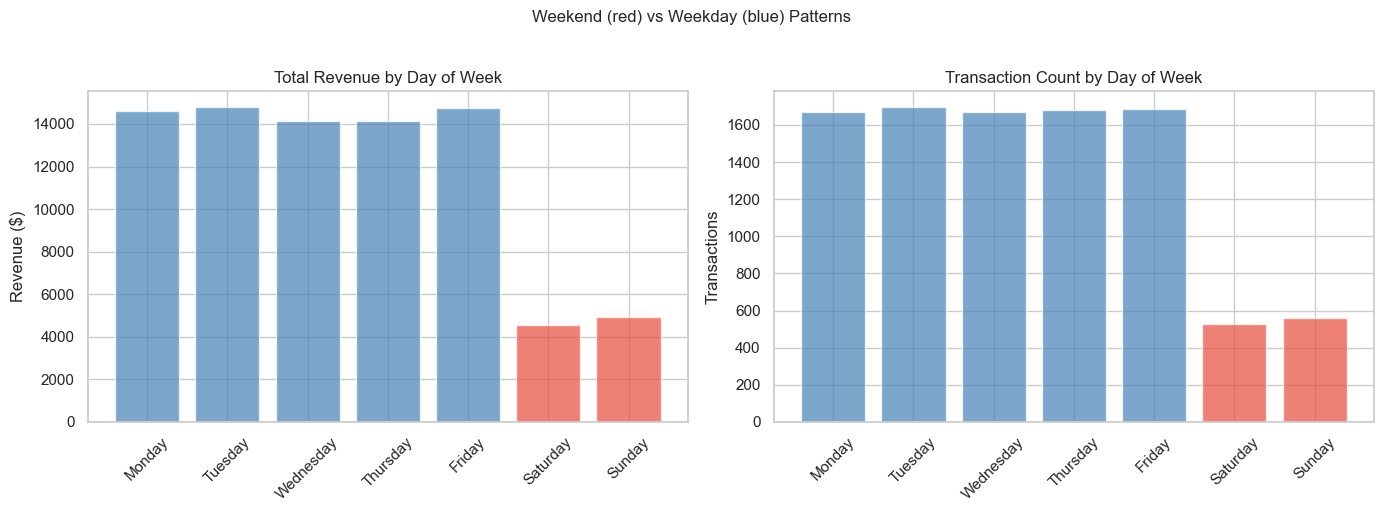

Weekend vs Weekday comparison:
         total_revenue  avg_transaction  count
Weekday        72428.0         8.623408   8399
Weekend         9504.5         8.767989   1084


In [11]:
df['day_of_week'] = df['Transaction Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow = df.groupby('day_of_week').agg(
    total_revenue=('Total Spent', 'sum'),
    avg_daily_revenue=('Total Spent', 'mean'),
    transactions=('Transaction ID', 'count')
).reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c' if d in ['Saturday', 'Sunday'] else 'steelblue' for d in day_order]
axes[0].bar(dow.index, dow['total_revenue'], color=colors, alpha=0.7)
axes[0].set_title('Total Revenue by Day of Week')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(dow.index, dow['transactions'], color=colors, alpha=0.7)
axes[1].set_title('Transaction Count by Day of Week')
axes[1].set_ylabel('Transactions')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Weekend (red) vs Weekday (blue) Patterns', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}day_of_week_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])
weekend_summary = df.groupby('is_weekend').agg(
    total_revenue=('Total Spent', 'sum'),
    avg_transaction=('Total Spent', 'mean'),
    count=('Transaction ID', 'count')
)
weekend_summary.index = ['Weekday', 'Weekend']
print('Weekend vs Weekday comparison:')
print(weekend_summary.to_string())

### 2.6 Monthly Seasonality & Quarterly Breakdown

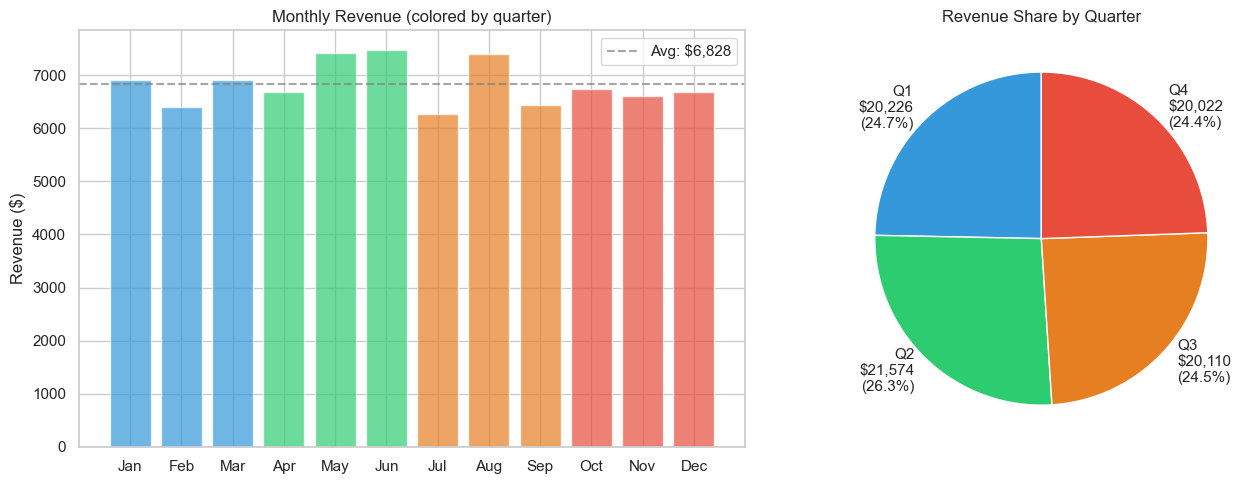

Quarterly revenue breakdown:
 Quarter  Revenue  Share
       1  20226.5   24.7
       2  21574.5   26.3
       3  20109.5   24.5
       4  20022.0   24.4


In [12]:
monthly['quarter'] = monthly['Transaction Date'].dt.quarter
quarterly = monthly.groupby('quarter')['revenue'].sum().reset_index()
quarterly.columns = ['Quarter', 'Revenue']
quarterly['Share'] = (quarterly['Revenue'] / quarterly['Revenue'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_names = monthly['Transaction Date'].dt.strftime('%b')
q_colors = {1: '#3498db', 2: '#2ecc71', 3: '#e67e22', 4: '#e74c3c'}
bar_colors = [q_colors[q] for q in monthly['quarter']]
axes[0].bar(month_names, monthly['revenue'], color=bar_colors, alpha=0.7)
axes[0].set_title('Monthly Revenue (colored by quarter)')
axes[0].set_ylabel('Revenue ($)')
axes[0].axhline(y=monthly['revenue'].mean(), color='gray', linestyle='--', alpha=0.7, label=f"Avg: ${monthly['revenue'].mean():,.0f}")
axes[0].legend()

axes[1].pie(quarterly['Revenue'], labels=[f"Q{q}\n${r:,.0f}\n({s}%)" for q, r, s in zip(quarterly['Quarter'], quarterly['Revenue'], quarterly['Share'])],
            colors=[q_colors[q] for q in quarterly['Quarter']], autopct='', startangle=90)
axes[1].set_title('Revenue Share by Quarter')

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}monthly_seasonality_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()

print('Quarterly revenue breakdown:')
print(quarterly.to_string(index=False))

In [13]:
strongest = monthly.loc[monthly['revenue'].idxmax()]
weakest = monthly.loc[monthly['revenue'].idxmin()]
weekend_pct = weekend_summary.loc['Weekend', 'count'] / len(df) * 100
weekday_pct = 100 - weekend_pct
q_min, q_max = quarterly['Share'].min(), quarterly['Share'].max()

print("### 2.7 Observations - Sales Trends\n")
print(f"1. Overall trend: Revenue is relatively stable (~${monthly['revenue'].min():,.0f}-${monthly['revenue'].max():,.0f}/month), no strong upward or downward trend")
print(f"2. Strongest/weakest months: {strongest['month_label']} (${strongest['revenue']:,.0f}) is the strongest; {weakest['month_label']} (${weakest['revenue']:,.0f}) is the weakest")
print(f"3. Growth pattern: Volatile MoM growth with no consistent direction - suggests a mature, stable business")
print(f"4. Day-of-week effect: Weekdays dominate (~{weekday_pct:.1f}% of transactions); weekend activity is minimal")
print(f"5. Seasonality: Revenue is evenly distributed across quarters ({q_min:.0f}-{q_max:.0f}% each) - no strong seasonal pattern")

### 2.7 Observations - Sales Trends

1. Overall trend: Revenue is relatively stable (~$6,268-$7,470/month), no strong upward or downward trend
2. Strongest/weakest months: Jun 2023 ($7,470) is the strongest; Jul 2023 ($6,268) is the weakest
3. Growth pattern: Volatile MoM growth with no consistent direction - suggests a mature, stable business
4. Day-of-week effect: Weekdays dominate (~88.6% of transactions); weekend activity is minimal
5. Seasonality: Revenue is evenly distributed across quarters (24-26% each) - no strong seasonal pattern


## 3. Regional Performance

=== Province Performance Summary ===
                 Province  revenue  transactions  units  avg_order  share_pct
         British Columbia  26998.0          3114   6247   8.669878       34.3
Newfoundland and Labrador  19709.0          2260   4501   8.720796       25.1
             Saskatchewan  16355.0          1876   3712   8.718017       20.8
                 Manitoba  15456.5          1819   3599   8.497251       19.6
                  Ontario    158.0            18     33   8.777778        0.2

=== Payment Method Revenue by Province ===
Payment Method               Cash  Credit Card  Digital Wallet
Province                                                      
British Columbia           6528.5      10556.5          8355.5
Manitoba                   3850.5       6342.0          4431.5
Newfoundland and Labrador  4773.0       7663.5          6187.0
Ontario                      45.0         86.0            17.0
Saskatchewan               4595.0       6313.5          4576.0

=== Locat

C:\Users\khatr\AppData\Local\Temp\ipykernel_17652\4165992299.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=province_summary, y='Province', x='revenue', palette='Blues_d', ax=axes[0])
C:\Users\khatr\AppData\Local\Temp\ipykernel_17652\4165992299.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=province_summary, y='Province', x='avg_order', palette='Oranges_d', ax=axes[1])


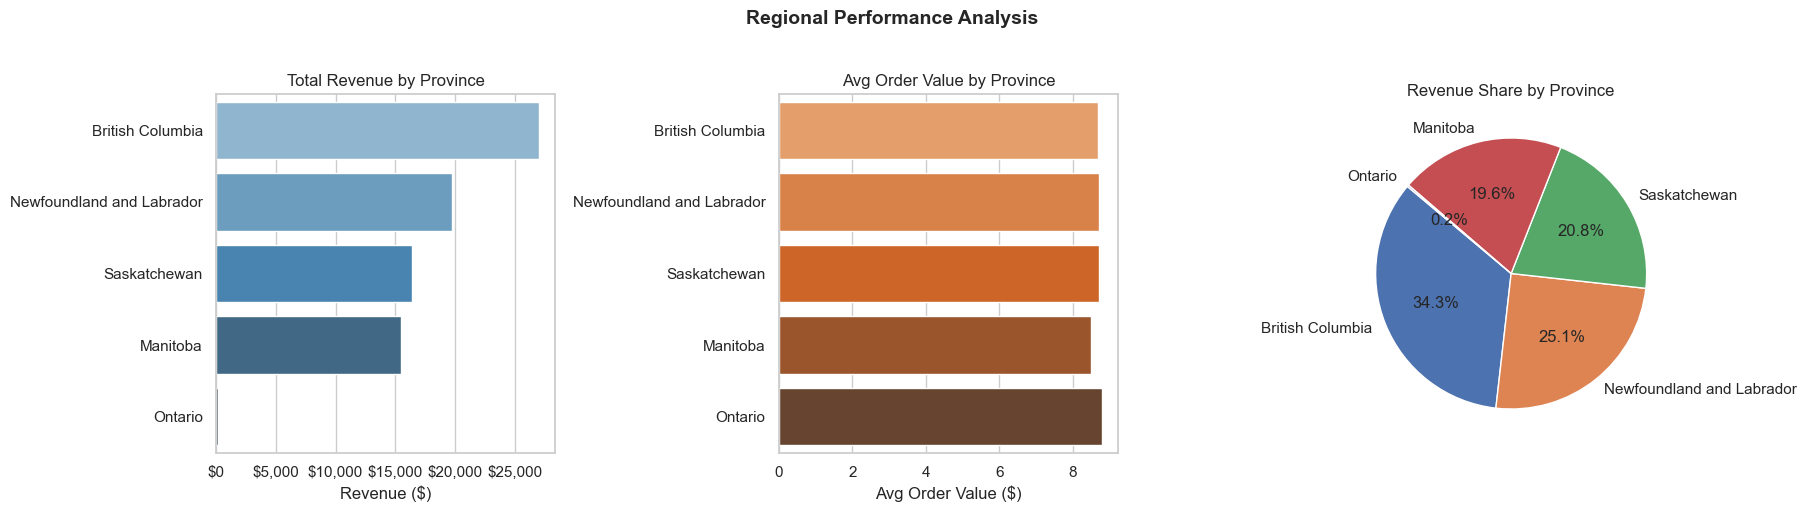

In [14]:
regional_df = df[df['Province'] != 'Unknown'].copy()

province_summary = (
    regional_df.groupby('Province')
    .agg(
        revenue=('Total Spent', 'sum'),
        transactions=('Transaction ID', 'count'),
        units=('Quantity', 'sum'),
        avg_order=('Total Spent', 'mean'),
    )
    .sort_values('revenue', ascending=False)
    .reset_index()
)
province_summary['share_pct'] = (
    province_summary['revenue'] / province_summary['revenue'].sum() * 100
).round(1)

print('=== Province Performance Summary ===')
print(province_summary.to_string(index=False))

# Payment method mix by province
payment_region = (
    regional_df[regional_df['Payment Method'] != 'Unknown']
    .groupby(['Province', 'Payment Method'])['Total Spent']
    .sum()
    .unstack(fill_value=0)
)
print('\n=== Payment Method Revenue by Province ===')
print(payment_region.to_string())

# Location type mix by province
location_region = (
    regional_df[regional_df['Location'] != 'Unknown']
    .groupby(['Province', 'Location'])['Total Spent']
    .sum()
    .unstack(fill_value=0)
)
print('\n=== Location Type Revenue by Province ===')
print(location_region.to_string())

# Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=province_summary, y='Province', x='revenue', palette='Blues_d', ax=axes[0])
axes[0].set_title('Total Revenue by Province')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.barplot(data=province_summary, y='Province', x='avg_order', palette='Oranges_d', ax=axes[1])
axes[1].set_title('Avg Order Value by Province')
axes[1].set_xlabel('Avg Order Value ($)')
axes[1].set_ylabel('')

axes[2].pie(
    province_summary['revenue'],
    labels=province_summary['Province'],
    autopct='%1.1f%%',
    startangle=140,
)
axes[2].set_title('Revenue Share by Province')

plt.suptitle('Regional Performance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}regional_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Product & Category Performance

=== Product Performance Summary ===
     Item  revenue  units  transactions  avg_price  avg_order  share_pct
 Sandwich  19472.0   2434          1224        8.0  15.908497       23.8
   Coffee  18389.0   5254          2660        3.5   6.913158       22.4
    Salad  12933.0   1437           720        9.0  17.962500       15.8
      Tea   8991.0   2997          1501        3.0   5.990007       11.0
Refresher   7690.0   1538           771        5.0   9.974060        9.4
    Juice   5661.0   1258           630        4.5   8.985714        6.9
   Cookie   4592.5   1837           910        2.5   5.046703        5.6
    Donut   4204.0   2102          1067        2.0   3.940019        5.1

=== Category Performance Summary ===
 Category  revenue  units  transactions  share_pct
Beverages  40731.0  11047          5562       49.7
     Food  41201.5   7810          3921       50.3

=== Top Product by Province ===
                 Province Top Item  Revenue
         British Columbia Sandwich   64

C:\Users\khatr\AppData\Local\Temp\ipykernel_17652\3298680601.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_summary, x='Item', y='revenue', palette='Blues_d', ax=axes[0, 0])
C:\Users\khatr\AppData\Local\Temp\ipykernel_17652\3298680601.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_summary, x='Item', y='units', palette='Greens_d', ax=axes[0, 1])
C:\Users\khatr\AppData\Local\Temp\ipykernel_17652\3298680601.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_summary, x='Item', y='avg_order', p

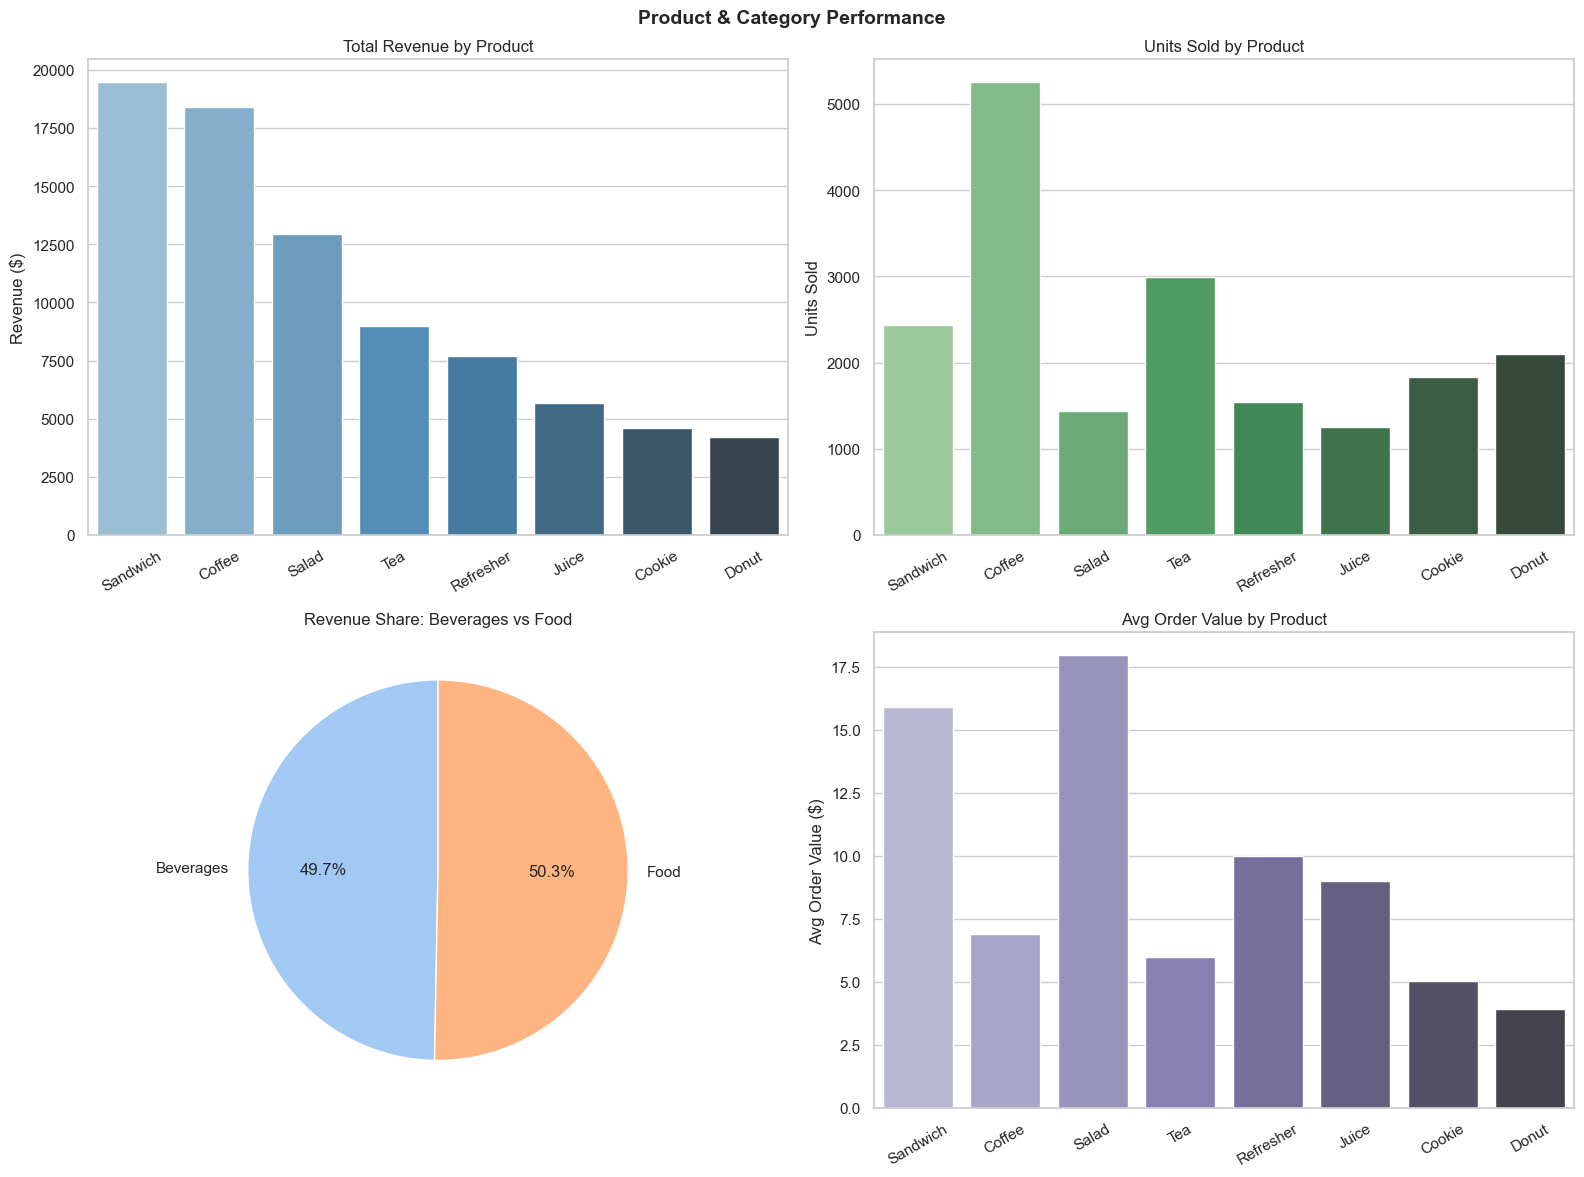

In [15]:
category_map = {
    'Coffee': 'Beverages', 'Tea': 'Beverages',
    'Refresher': 'Beverages', 'Juice': 'Beverages',
    'Donut': 'Food', 'Cookie': 'Food',
    'Salad': 'Food', 'Sandwich': 'Food',
}
df['Category'] = df['Item'].map(category_map)

product_summary = (
    df.groupby('Item')
    .agg(
        revenue=('Total Spent', 'sum'),
        units=('Quantity', 'sum'),
        transactions=('Transaction ID', 'count'),
        avg_price=('Price Per Unit', 'mean'),
        avg_order=('Total Spent', 'mean'),
    )
    .sort_values('revenue', ascending=False)
    .reset_index()
)
product_summary['share_pct'] = (
    product_summary['revenue'] / product_summary['revenue'].sum() * 100
).round(1)

print('=== Product Performance Summary ===')
print(product_summary.to_string(index=False))

category_summary = (
    df.groupby('Category')
    .agg(
        revenue=('Total Spent', 'sum'),
        units=('Quantity', 'sum'),
        transactions=('Transaction ID', 'count'),
    )
    .reset_index()
)
category_summary['share_pct'] = (
    category_summary['revenue'] / category_summary['revenue'].sum() * 100
).round(1)

print('\n=== Category Performance Summary ===')
print(category_summary.to_string(index=False))

top_by_province = (
    df.groupby(['Province', 'Item'])['Total Spent']
    .sum().reset_index()
    .sort_values(['Province', 'Total Spent'], ascending=[True, False])
    .groupby('Province').first().reset_index()
    .rename(columns={'Item': 'Top Item', 'Total Spent': 'Revenue'})
)
print('\n=== Top Product by Province ===')
print(top_by_province.to_string(index=False))

# Charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=product_summary, x='Item', y='revenue', palette='Blues_d', ax=axes[0, 0])
axes[0, 0].set_title('Total Revenue by Product')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=30)

sns.barplot(data=product_summary, x='Item', y='units', palette='Greens_d', ax=axes[0, 1])
axes[0, 1].set_title('Units Sold by Product')
axes[0, 1].set_ylabel('Units Sold')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=30)

axes[1, 0].pie(
    category_summary['revenue'],
    labels=category_summary['Category'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')[:2],
)
axes[1, 0].set_title('Revenue Share: Beverages vs Food')

sns.barplot(data=product_summary, x='Item', y='avg_order', palette='Purples_d', ax=axes[1, 1])
axes[1, 1].set_title('Avg Order Value by Product')
axes[1, 1].set_ylabel('Avg Order Value ($)')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.suptitle('Product & Category Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}product_category_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Location Type Analysis

Compare In-store, Takeaway, and Unknown channels by revenue, volume, and average spend.

=== Location Type Summary ===
Location  revenue  transactions  avg_spend  avg_quantity  share_pct
In-store  48293.5          5611   8.606933      1.997861       58.9
Takeaway  26364.0          3040   8.672368      1.977632       32.2
 Unknown   7275.0           832   8.743990      1.965144        8.9

=== Product Revenue by Location Type ===
Item       Coffee  Cookie   Donut   Juice  Refresher   Salad  Sandwich     Tea
Location                                                                      
In-store  11154.5  2540.0  2558.0  3582.0     4530.0  7074.0   11416.0  5439.0
Takeaway   5645.5  1632.5  1268.0  1692.0     2495.0  4590.0    6176.0  2865.0
Unknown    1589.0   420.0   378.0   387.0      665.0  1269.0    1880.0   687.0


C:\Users\khatr\AppData\Local\Temp\ipykernel_17652\476720609.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=location_summary, x='Location', y='revenue', palette='Blues_d', ax=axes[0])
C:\Users\khatr\AppData\Local\Temp\ipykernel_17652\476720609.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=location_summary, x='Location', y='avg_spend', palette='Oranges_d', ax=axes[1])
C:\Users\khatr\AppData\Local\Temp\ipykernel_17652\476720609.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=location_summary, x='Location', y='tr

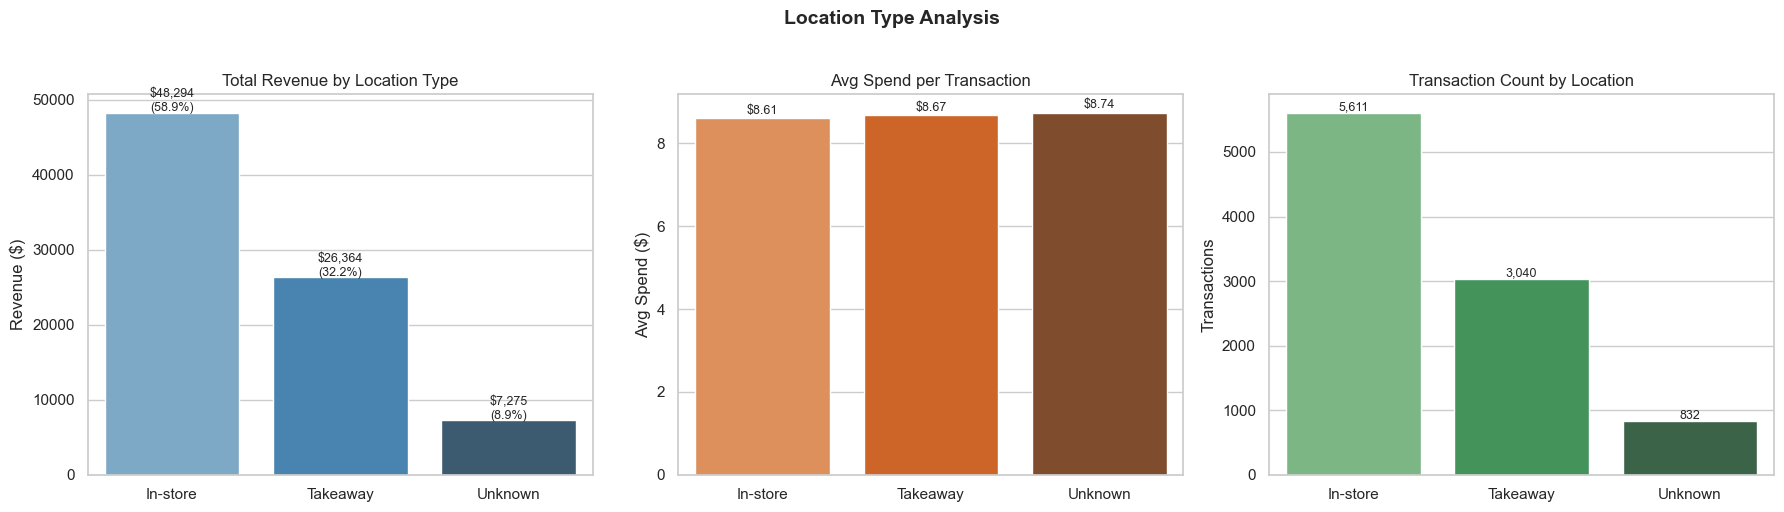

In [16]:
location_summary = (
    df.groupby('Location')
    .agg(
        revenue=('Total Spent', 'sum'),
        transactions=('Transaction ID', 'count'),
        avg_spend=('Total Spent', 'mean'),
        avg_quantity=('Quantity', 'mean'),
    )
    .sort_values('revenue', ascending=False)
    .reset_index()
)
location_summary['share_pct'] = (
    location_summary['revenue'] / location_summary['revenue'].sum() * 100
).round(1)

print('=== Location Type Summary ===')
print(location_summary.to_string(index=False))

# Product mix by location
product_by_location = (
    df.groupby(['Location', 'Item'])['Total Spent']
    .sum()
    .unstack(fill_value=0)
)
print('\n=== Product Revenue by Location Type ===')
print(product_by_location.to_string())

# Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=location_summary, x='Location', y='revenue', palette='Blues_d', ax=axes[0])
axes[0].set_title('Total Revenue by Location Type')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xlabel('')
for i, row in location_summary.iterrows():
    axes[0].text(i, row['revenue'] + 200, f"${row['revenue']:,.0f}\n({row['share_pct']}%)",
                 ha='center', fontsize=9)

sns.barplot(data=location_summary, x='Location', y='avg_spend', palette='Oranges_d', ax=axes[1])
axes[1].set_title('Avg Spend per Transaction')
axes[1].set_ylabel('Avg Spend ($)')
axes[1].set_xlabel('')
for i, row in location_summary.iterrows():
    axes[1].text(i, row['avg_spend'] + 0.1, f"${row['avg_spend']:.2f}", ha='center', fontsize=9)

sns.barplot(data=location_summary, x='Location', y='transactions', palette='Greens_d', ax=axes[2])
axes[2].set_title('Transaction Count by Location')
axes[2].set_ylabel('Transactions')
axes[2].set_xlabel('')
for i, row in location_summary.iterrows():
    axes[2].text(i, row['transactions'] + 30, f"{row['transactions']:,}", ha='center', fontsize=9)

plt.suptitle('Location Type Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}location_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Payment Method Analysis

Distribution, average spend, and monthly trends by payment method.

=== Payment Method Summary ===
Payment Method  revenue  transactions  avg_spend  avg_quantity  share_pct
   Credit Card  32357.5          3686   8.778486      2.016007       39.5
Digital Wallet  24500.0          2849   8.599509      1.965251       29.9
          Cash  20571.0          2424   8.486386      1.970297       25.1
       Unknown   4504.0           524   8.595420      2.005725        5.5


C:\Users\khatr\AppData\Local\Temp\ipykernel_17652\4268431852.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_summary, x='Payment Method', y='revenue', palette='Blues_d', ax=axes[0])
C:\Users\khatr\AppData\Local\Temp\ipykernel_17652\4268431852.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_summary, x='Payment Method', y='avg_spend', palette='Oranges_d', ax=axes[1])
C:\Users\khatr\AppData\Local\Temp\ipykernel_17652\4268431852.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_summary, x='Paym

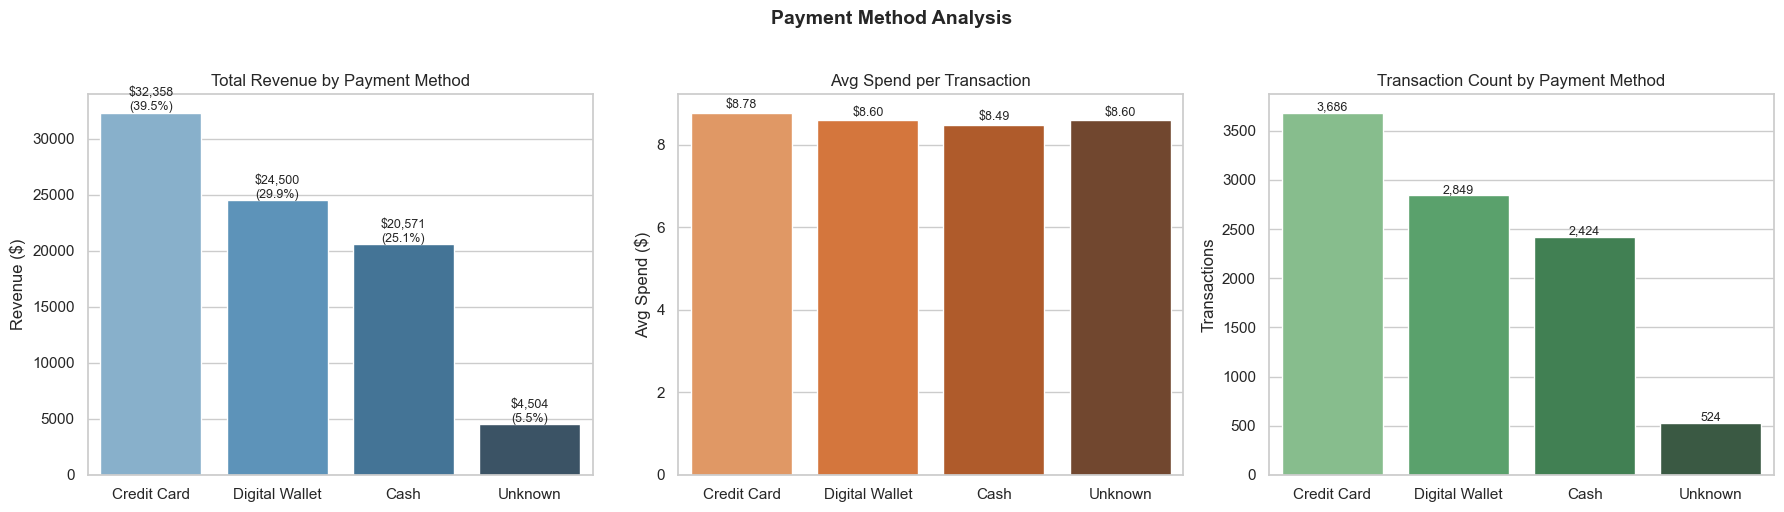

In [17]:
### 6.1 Distribution & Average Spend

payment_summary = (
    df.groupby('Payment Method')
    .agg(
        revenue=('Total Spent', 'sum'),
        transactions=('Transaction ID', 'count'),
        avg_spend=('Total Spent', 'mean'),
        avg_quantity=('Quantity', 'mean'),
    )
    .sort_values('revenue', ascending=False)
    .reset_index()
)
payment_summary['share_pct'] = (
    payment_summary['revenue'] / payment_summary['revenue'].sum() * 100
).round(1)

print('=== Payment Method Summary ===')
print(payment_summary.to_string(index=False))

# Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=payment_summary, x='Payment Method', y='revenue', palette='Blues_d', ax=axes[0])
axes[0].set_title('Total Revenue by Payment Method')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xlabel('')
for i, row in payment_summary.iterrows():
    axes[0].text(i, row['revenue'] + 200, f"${row['revenue']:,.0f}\n({row['share_pct']}%)",
                 ha='center', fontsize=9)

sns.barplot(data=payment_summary, x='Payment Method', y='avg_spend', palette='Oranges_d', ax=axes[1])
axes[1].set_title('Avg Spend per Transaction')
axes[1].set_ylabel('Avg Spend ($)')
axes[1].set_xlabel('')
for i, row in payment_summary.iterrows():
    axes[1].text(i, row['avg_spend'] + 0.1, f"${row['avg_spend']:.2f}", ha='center', fontsize=9)

sns.barplot(data=payment_summary, x='Payment Method', y='transactions', palette='Greens_d', ax=axes[2])
axes[2].set_title('Transaction Count by Payment Method')
axes[2].set_ylabel('Transactions')
axes[2].set_xlabel('')
for i, row in payment_summary.iterrows():
    axes[2].text(i, row['transactions'] + 20, f"{row['transactions']:,}", ha='center', fontsize=9)

plt.suptitle('Payment Method Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}payment_method_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

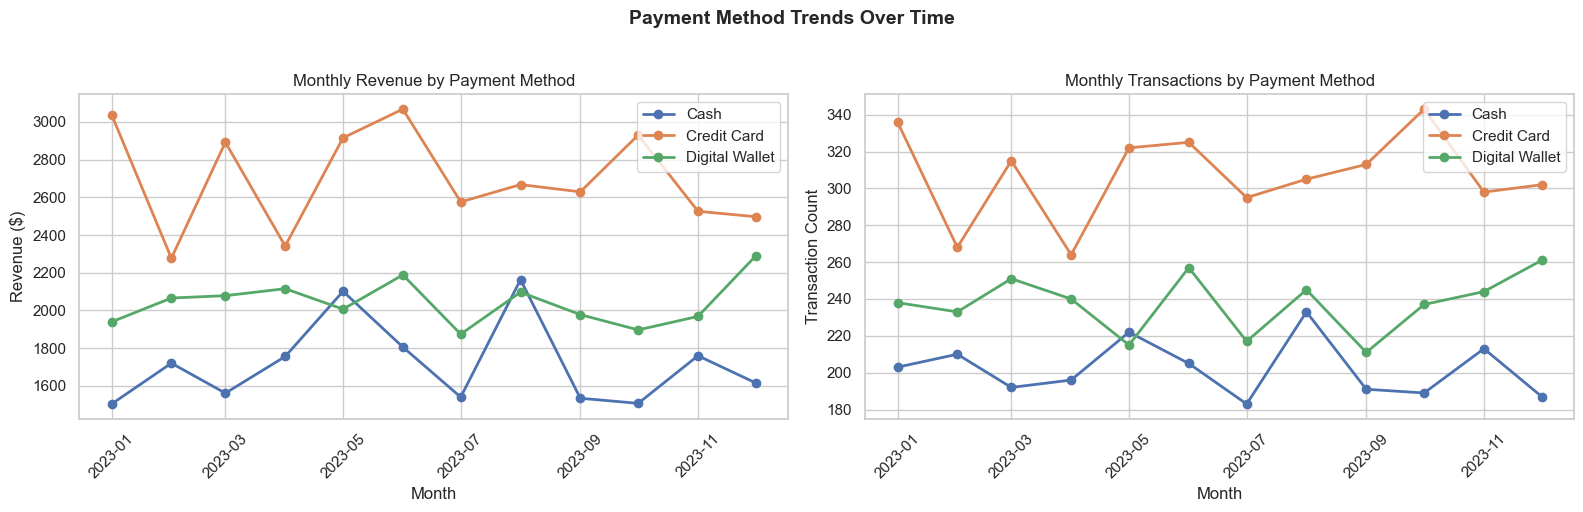

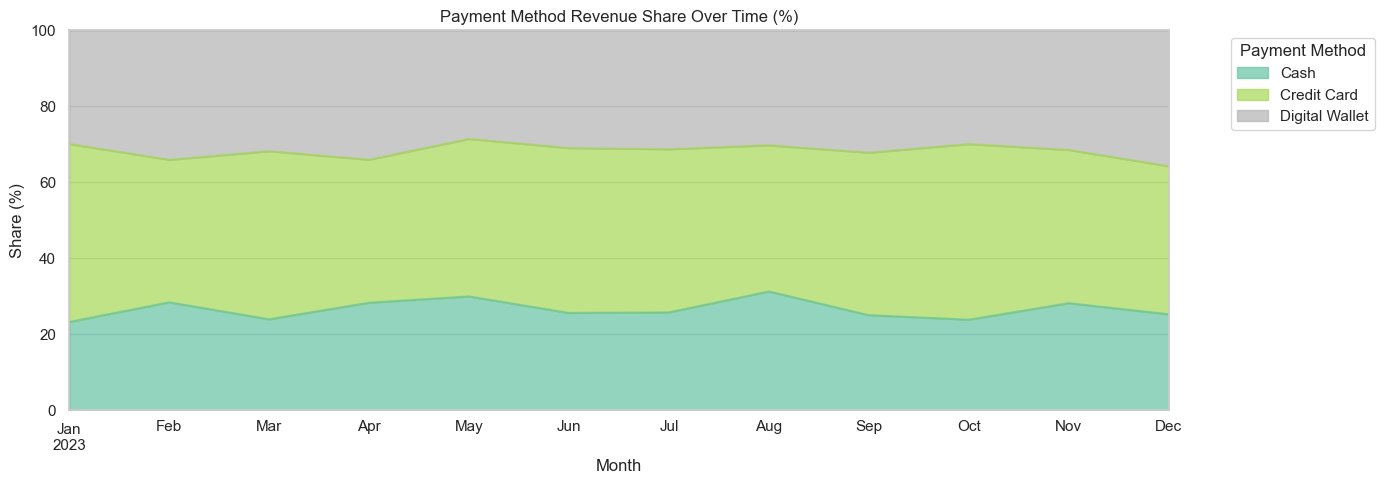

In [18]:
### 6.2 Payment Method Trends Over Time

payment_known = df[df['Payment Method'] != 'Unknown'].copy()

monthly_payment = (
    payment_known
    .groupby([pd.Grouper(key='Transaction Date', freq='MS'), 'Payment Method'])
    .agg(revenue=('Total Spent', 'sum'), transactions=('Transaction ID', 'count'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for method in sorted(payment_known['Payment Method'].unique()):
    subset = monthly_payment[monthly_payment['Payment Method'] == method]
    axes[0].plot(subset['Transaction Date'], subset['revenue'], marker='o', label=method, linewidth=2)
    axes[1].plot(subset['Transaction Date'], subset['transactions'], marker='o', label=method, linewidth=2)

axes[0].set_title('Monthly Revenue by Payment Method')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xlabel('Month')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].set_title('Monthly Transactions by Payment Method')
axes[1].set_ylabel('Transaction Count')
axes[1].set_xlabel('Month')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Payment Method Trends Over Time', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}payment_method_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Monthly share of each payment method
monthly_share = monthly_payment.pivot_table(
    index='Transaction Date', columns='Payment Method', values='revenue', fill_value=0
)
monthly_share_pct = monthly_share.div(monthly_share.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
monthly_share_pct.plot.area(ax=ax, alpha=0.7, colormap='Set2')
ax.set_title('Payment Method Revenue Share Over Time (%)')
ax.set_ylabel('Share (%)')
ax.set_xlabel('Month')
ax.set_ylim(0, 100)
ax.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}payment_method_share_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
### A3 Observations - Product, Region & Payment Method

top_province = province_summary.iloc[0]
bottom_province = province_summary.iloc[-1]
top_product = product_summary.iloc[0]
bottom_product = product_summary.iloc[-1]
top_location = location_summary.iloc[0]
top_payment = payment_summary[payment_summary['Payment Method'] != 'Unknown'].iloc[0]

print("### A3 Observations\n")
print(f"1. Regional concentration: {top_province['Province']} leads with {top_province['share_pct']}% revenue share; {bottom_province['Province']} is smallest at {bottom_province['share_pct']}%")
print(f"2. Product dominance: {top_product['Item']} is the top revenue driver ({top_product['share_pct']}%); {bottom_product['Item']} is lowest ({bottom_product['share_pct']}%)")
print(f"3. Beverages vs Food: {category_summary.loc[category_summary['Category'] == 'Beverages', 'share_pct'].values[0]}% revenue from Beverages vs {category_summary.loc[category_summary['Category'] == 'Food', 'share_pct'].values[0]}% from Food")
print(f"4. Location split: {top_location['Location']} dominates with {top_location['share_pct']}% of revenue; Unknown location accounts for {location_summary.loc[location_summary['Location'] == 'Unknown', 'share_pct'].values[0]}% (data quality gap)")
print(f"5. Payment methods: {top_payment['Payment Method']} leads with {top_payment['share_pct']}% of revenue; all known methods have similar avg spend (~${top_payment['avg_spend']:.2f})")
print(f"6. Payment trends: Payment method shares are relatively stable month-over-month, no major shifts in customer payment preferences")

### A3 Observations

1. Regional concentration: British Columbia leads with 34.3% revenue share; Ontario is smallest at 0.2%
2. Product dominance: Sandwich is the top revenue driver (23.8%); Donut is lowest (5.1%)
3. Beverages vs Food: 49.7% revenue from Beverages vs 50.3% from Food
4. Location split: In-store dominates with 58.9% of revenue; Unknown location accounts for 8.9% (data quality gap)
5. Payment methods: Credit Card leads with 39.5% of revenue; all known methods have similar avg spend (~$8.78)
6. Payment trends: Payment method shares are relatively stable month-over-month, no major shifts in customer payment preferences


## 7. Business Insights Summary

Document each insight in the format: **Finding - Evidence - Recommended Action**

1. **Insight 1:** ...
2. **Insight 2:** ...
3. **Insight 3:** ...